Размер датасета: (4080, 4)

Первые строки:
              species  length  weight  w_l_ratio
0  Anabas testudineus   10.66    3.45       0.32
1  Anabas testudineus    6.91    3.27       0.47
2  Anabas testudineus    8.38    3.46       0.41
3  Anabas testudineus    7.57    3.36       0.44
4  Anabas testudineus   10.83    3.38       0.31

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    4080 non-null   object 
 1   length     4080 non-null   float64
 2   weight     4080 non-null   float64
 3   w_l_ratio  4080 non-null   float64
dtypes: float64(3), object(1)
memory usage: 127.6+ KB
None

Описание признаков:
            count       mean       std   min      25%    50%     75%    max
length     4080.0  17.353544  7.114684  6.36  11.3275  17.35  22.585  33.86
weight     4080.0   3.739875  1.040365  2.05   3.0700   3.31   

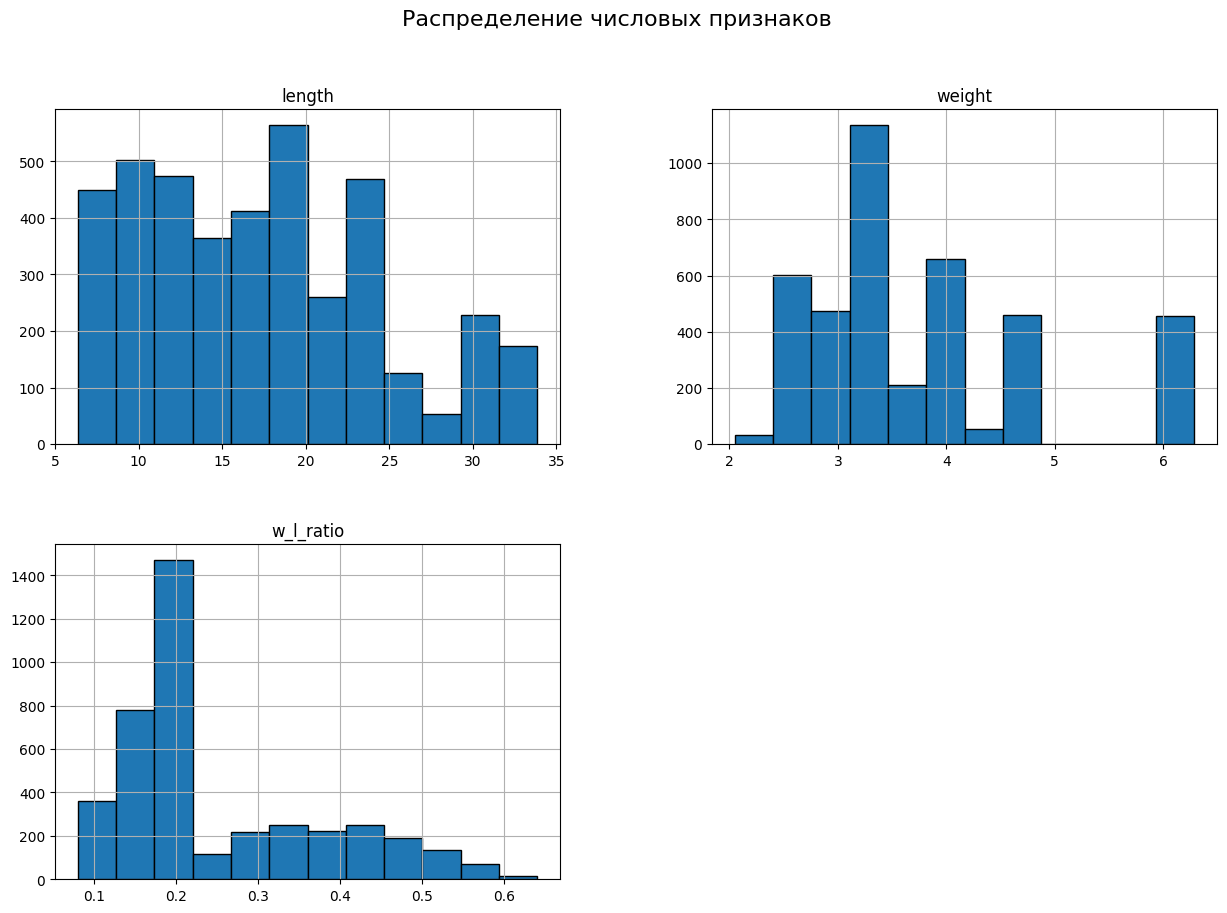

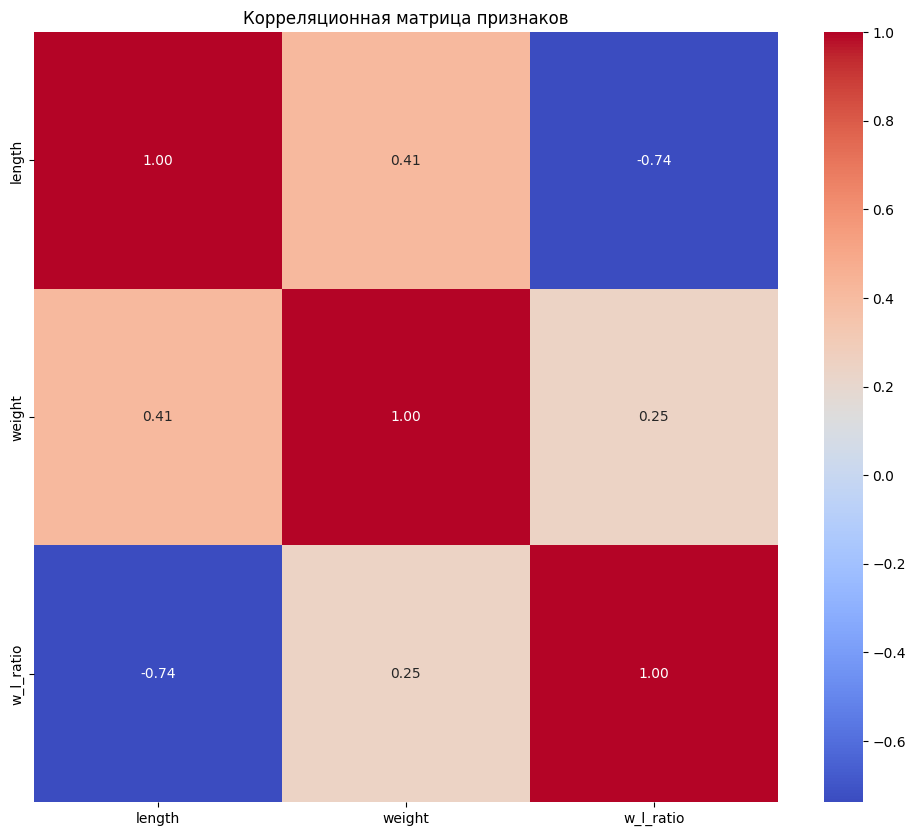

In [7]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, normaltest
import seaborn as sns

# Загрузка данных
df = pd.read_csv('fish_data.csv')
df = df.fillna(df.mean(numeric_only=True))

# Описание и базовый анализ
num_cols = df.columns.drop('species')

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe().T)
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Асимметрия и эксцесс
param_data = {'Параметр': [], 'Асимметрия': [], 'Эксцесс': []}
for col in num_cols:
    param_data['Параметр'].append(col)
    param_data['Асимметрия'].append(skew(df[col].dropna()))
    param_data['Эксцесс'].append(kurtosis(df[col].dropna()))
summary_df = pd.DataFrame(param_data)
print(summary_df)

# Нормальность распределения (тест Д’Агостино-Пирсона)
print("\nПроверка нормальности распределения:")
for col in num_cols:
    stat, p = normaltest(df[col].dropna())
    print(f"{col}: статистика={stat:.4f}, p-значение={p:.4f}")
    if p > 0.05:
        print(" → распределение близко к нормальному\n")
    else:
        print(" → распределение отличается от нормального\n")

# Гистограммы для числовых признаков
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))
df[num_cols].hist(bins=count_of_bins, figsize=(15, 10), edgecolor="black")
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

# Корреляционный анализ
plt.figure(figsize=(12, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

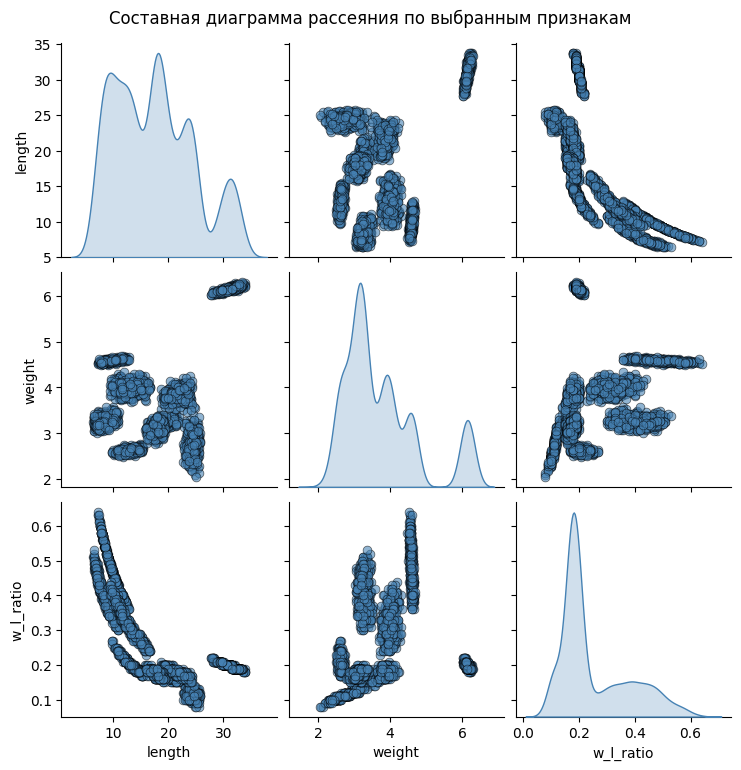

In [ ]:
sns.pairplot(
    df,
    diag_kind='kde',
    plot_kws={'color': 'steelblue', 'alpha': 0.6, 's': 40, 'edgecolor': 'k'},
    diag_kws={'color': 'steelblue'}
)
plt.suptitle("Составная диаграмма рассеяния по выбранным признакам", y=1.02)
plt.show()